<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/GET_FII_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [2]:
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator,YearLocator

In [3]:
# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'HVz1H6BP'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '99926000',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)

In [4]:
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import yfinance as yf

In [5]:
import numpy as np
import pandas as pd
#from pykalman import KalmanFilter
#import pandas_ta as ta

In [6]:
nif=nifty_data_format

In [7]:
nif.tail(2)

,Open,High,Low,Close,Volume
Date,,,,,
2026-05-21,23830.05,23859.90,23596.6,23654.7,0
2026-05-22,23671.20,23835.65,23671.0,23719.3,0


In [8]:
nif.head(2)
nif.reset_index(inplace=True)

In [9]:
fii=pd.read_csv('https://docs.google.com/spreadsheets/d/16JdPcqk_y9Hyiya97zBLSUfF4UNfniwDDjqPOFHjoPQ/export?format=csv')

In [10]:
# Convert both Date columns to datetime
nif["Date"] = pd.to_datetime(nif["Date"])
fii["Date"] = pd.to_datetime(fii["Date"])

# Remove timestamp part from df2
nif["Date"] = nif["Date"].dt.date
fii["Date"] = fii["Date"].dt.date

In [11]:
fii_fig = pd.merge(fii, nif, on="Date", how="inner")

In [12]:
fii_fig.set_index('Date',inplace=True)

# Change Here

In [13]:
fii_fig['Cash']=fii_fig.FIICash+fii_fig.DIIcash

In [14]:
fii_fig['Cashfut']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signalfutcash']=fii_fig['Cashfut'].ewm(span=22,adjust=False).mean()
fii_fig['signal10futcash']=fii_fig['Cashfut'].ewm(span=10,adjust=False).mean()

# Plot FII minus DII

In [15]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=25,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=10,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [16]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=100, adjust=False).mean()-fii_fig['Cash'].ewm(span=250, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=45,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=20,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [17]:
fii_fig['macd']=fii_fig['DIIcash'].ewm(span=50, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=35,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']

In [18]:
fii_fig['macdx']=fii_fig['FIICash'].ewm(span=50, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signalx']=fii_fig['macdx'].ewm(span=35,adjust=False).mean()
fii_fig['signal10x']=fii_fig['macdx'].ewm(span=10,adjust=False).mean()
fii_fig['histx']=fii_fig['macdx']-fii_fig['signalx']

# Plot FII , DII , Difference comparison

In [19]:
fii_fig['macd']=fii_fig['FIICash'].ewm(span=20, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']


In [20]:
fii_fig['macd_dom']=fii_fig['DIIcash'].ewm(span=20, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal_dom']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['signal_dom_10']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['hist_dom']=fii_fig['macd_dom']-fii_fig['signal_dom']

In [21]:
fii_fig['MA200']=fii_fig.Close.rolling(window=200).mean()
fii_fig['MA20']=fii_fig.Close.rolling(window=20).mean()
fii_fig['MA13']=fii_fig.Close.rolling(window=13).mean()
fii_fig['MA26']=fii_fig.Close.rolling(window=26).mean()
fii_fig['MA12']=fii_fig.Close.ewm(span=12,adjust=False).mean()
# --------------------------
# MACD
# --------------------------
fii_fig["macd_impulse"] = fii_fig["MA12"] - fii_fig["MA26"]

# MACD Signal
fii_fig["macd_signal"] = fii_fig["macd_impulse"].ewm(span=9, adjust=False).mean()

# MACD Histogram
fii_fig["macd_hist"] = fii_fig["macd_impulse"] - fii_fig["macd_signal"]

In [22]:
fii_fig["ema_slope"] = fii_fig["MA13"].diff()
fii_fig["macd_slope"] = fii_fig["macd_hist"].diff()

fii_fig["impulse"] = "blue"

fii_fig.loc[
    (fii_fig["ema_slope"] > 0) & (fii_fig["macd_slope"] > 0),
    "impulse"
] = "green"

fii_fig.loc[
    (fii_fig["ema_slope"] < 0) & (fii_fig["macd_slope"] < 0),
    "impulse"
] = "red"

In [23]:
fii_fig.tail(2)

,FIICash,DIIcash,Open,High,Low,Close,Volume,Cash,Cashfut,signalfutcash,...,MA20,MA13,MA26,MA12,macd_impulse,macd_signal,macd_hist,ema_slope,macd_slope,impulse
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-21,-1349.0,2492.0,23830.05,23859.90,23596.6,23654.7,0,1143.0,-259.262058,-433.233993,...,23905.10,23799.176923,23987.219231,23738.68255,-248.53668,-108.911619,-139.625061,-26.373077,34.863634,blue
2026-05-22,-4357.0,4991.0,23671.20,23835.65,23671.0,23719.3,0,634.0,-255.264286,-417.758366,...,23872.16,23775.061538,23982.475000,23735.70062,-246.77438,-136.484172,-110.290209,-24.115385,29.334852,blue


# Plot Smart Money (FII)

In [24]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd'], mode='lines', name = 'macd'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=df.Date, y=df['signal'], mode='lines', name = 'signal'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date, y=df['signal10'], mode='lines', name = 'signal10'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="Smart Money And Nifty")

fig.show()

In [25]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
#nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money DII","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd_dom'], mode='lines', name = 'macd'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date,y=df['macd_dom'].rolling(window=10).mean(),mode='lines',name='moving-average 10'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="DII Money And Nifty")

fig.show()

In [26]:
fii_fig['macd_z'] = -(
    fii_fig['macd'] - fii_fig['macd'].rolling(20).mean()
) / fii_fig['macd'].rolling(20).std()

In [27]:
fii_fig.reset_index(inplace=True)

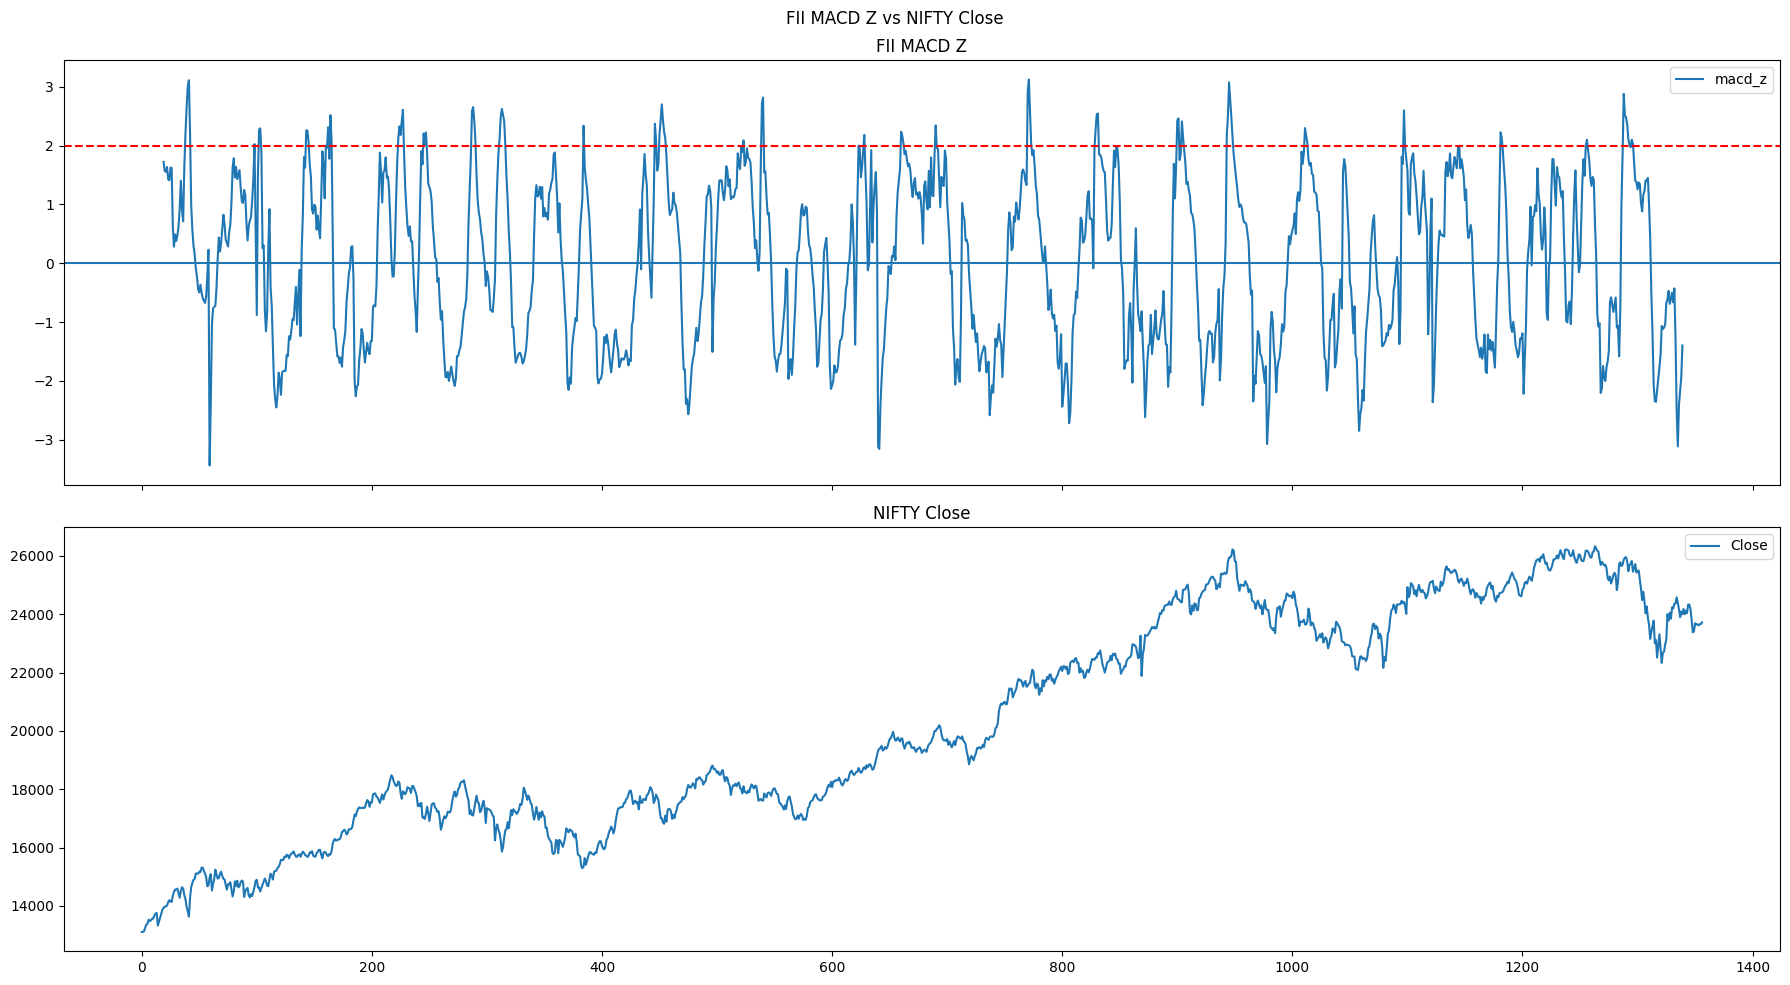

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# First subplot
fii_fig['macd_z'].plot(ax=axes[0])
axes[0].axhline(y=0)
axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])
axes[0].axhline(y=2, color='red', linestyle='--')

# Second subplot
nif['Close'].plot(ax=axes[1])
axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])

plt.suptitle('FII MACD Z vs NIFTY Close')
plt.tight_layout()

plt.show()

In [29]:

# =========================
# --- EMA 13 Calculation ---
# =========================
fii_fig['ema13'] = fii_fig['Close'].ewm(span=13, adjust=False).mean()

# =========================
# --- MACD Calculation ---
# =========================
ema12 = fii_fig['Close'].ewm(span=12, adjust=False).mean()
ema26 = fii_fig['Close'].ewm(span=26, adjust=False).mean()

fii_fig['macd'] = ema12 - ema26

# =========================
# --- Elder Impulse Logic ---
# =========================

ema_up = fii_fig['ema13'] > fii_fig['ema13'].shift(1)
ema_down = fii_fig['ema13'] < fii_fig['ema13'].shift(1)

macd_up = fii_fig['macd'] > fii_fig['macd'].shift(1)
macd_down = fii_fig['macd'] < fii_fig['macd'].shift(1)

# Default = Blue
fii_fig['impulse'] = 'blue'

# Green impulse
fii_fig.loc[ema_up & macd_up, 'impulse'] = 'green'

# Red impulse
fii_fig.loc[ema_down & macd_down, 'impulse'] = 'red'


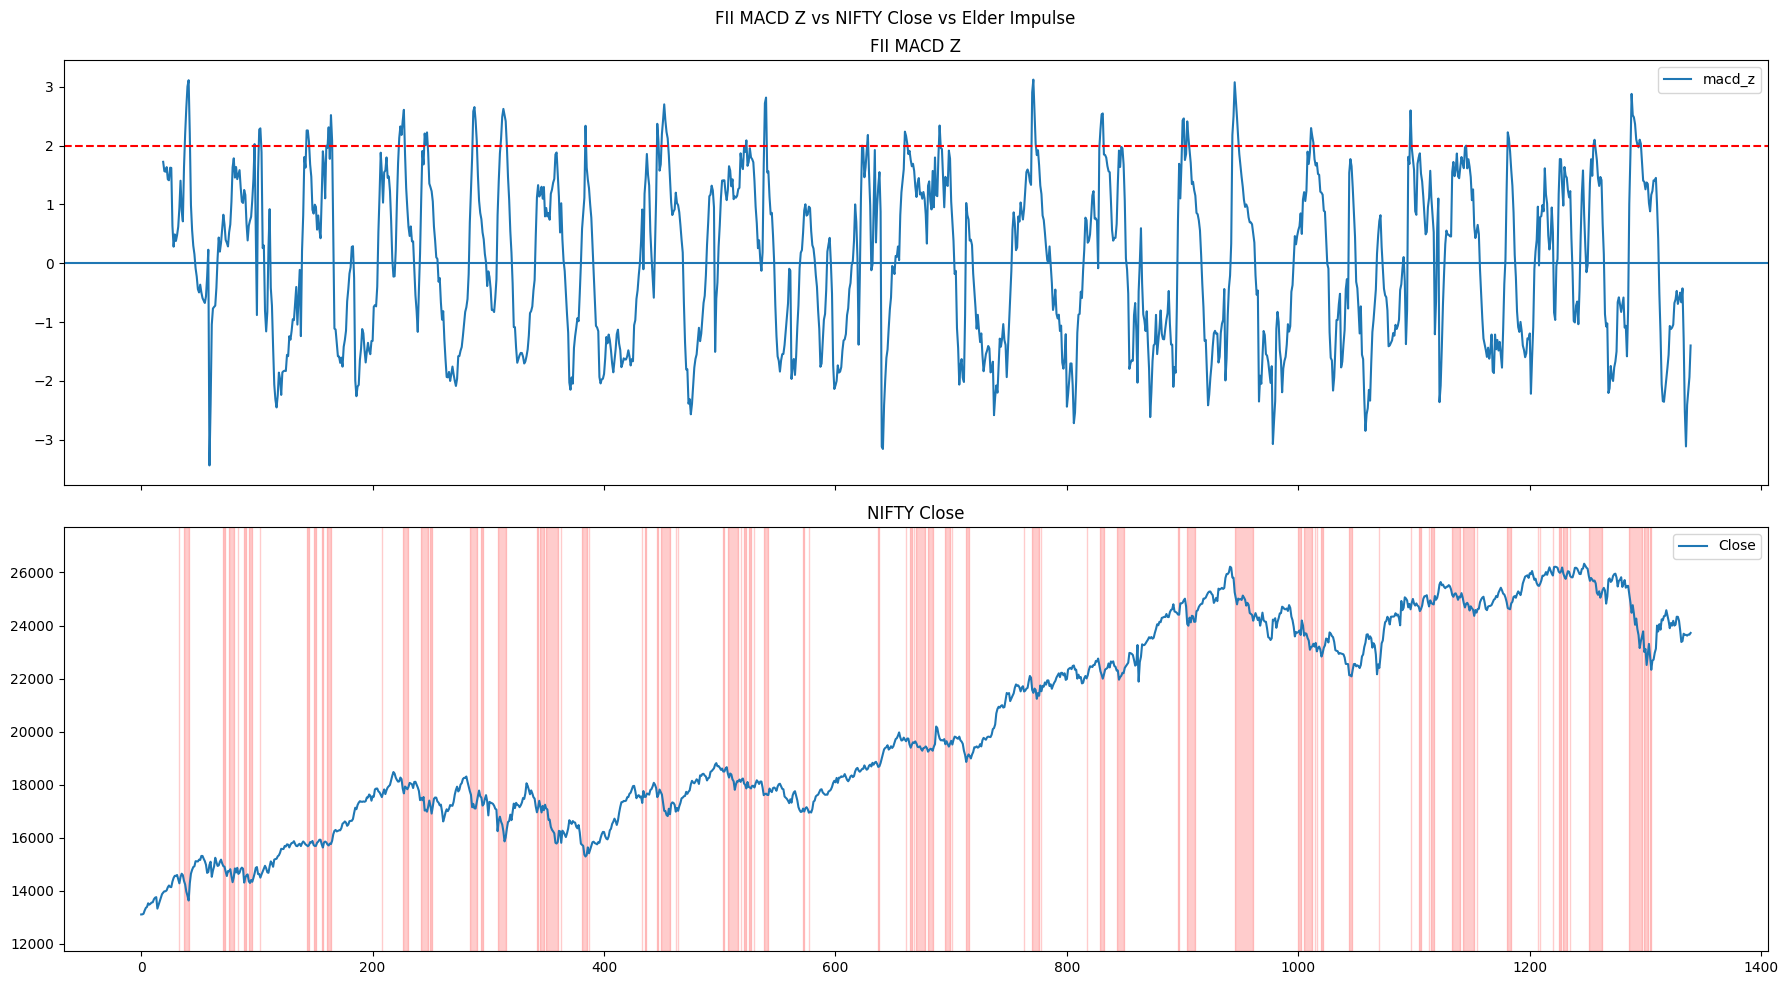

In [30]:

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- First subplot ---
fii_fig['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])

# --- Second subplot ---
fii_fig['Close'].plot(ax=axes[1])

# Condition
condition = (fii_fig['macd_z'] > 0.5) & (fii_fig['impulse'] == 'red')

# Red background
axes[1].fill_between(
    fii_fig.index,
    0,
    1,
    where=condition,
    color='red',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
)

axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])
'''
# ======================================================
# --- Third subplot : Elder Impulse ---
# ======================================================

# Plot close lightly in background
fii_fig['Close'].plot(
    ax=axes[2],
    color='black',
    alpha=0.4
)

# Green impulse background
axes[2].fill_between(
    combined.index,
    0,
    1,
    where=combined['impulse'] == 'green',
    color='green',
    alpha=0.3,
    transform=axes[2].get_xaxis_transform()
)

# Red impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'red',
    color='red',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)

# Blue impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'blue',
    color='blue',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)

axes[2].set_title('Elder Impulse System except Green')
axes[2].legend(['Close'])
'''


# ======================================================
# --- Final Layout ---
# ======================================================

plt.suptitle('FII MACD Z vs NIFTY Close vs Elder Impulse')

plt.tight_layout()

plt.show()

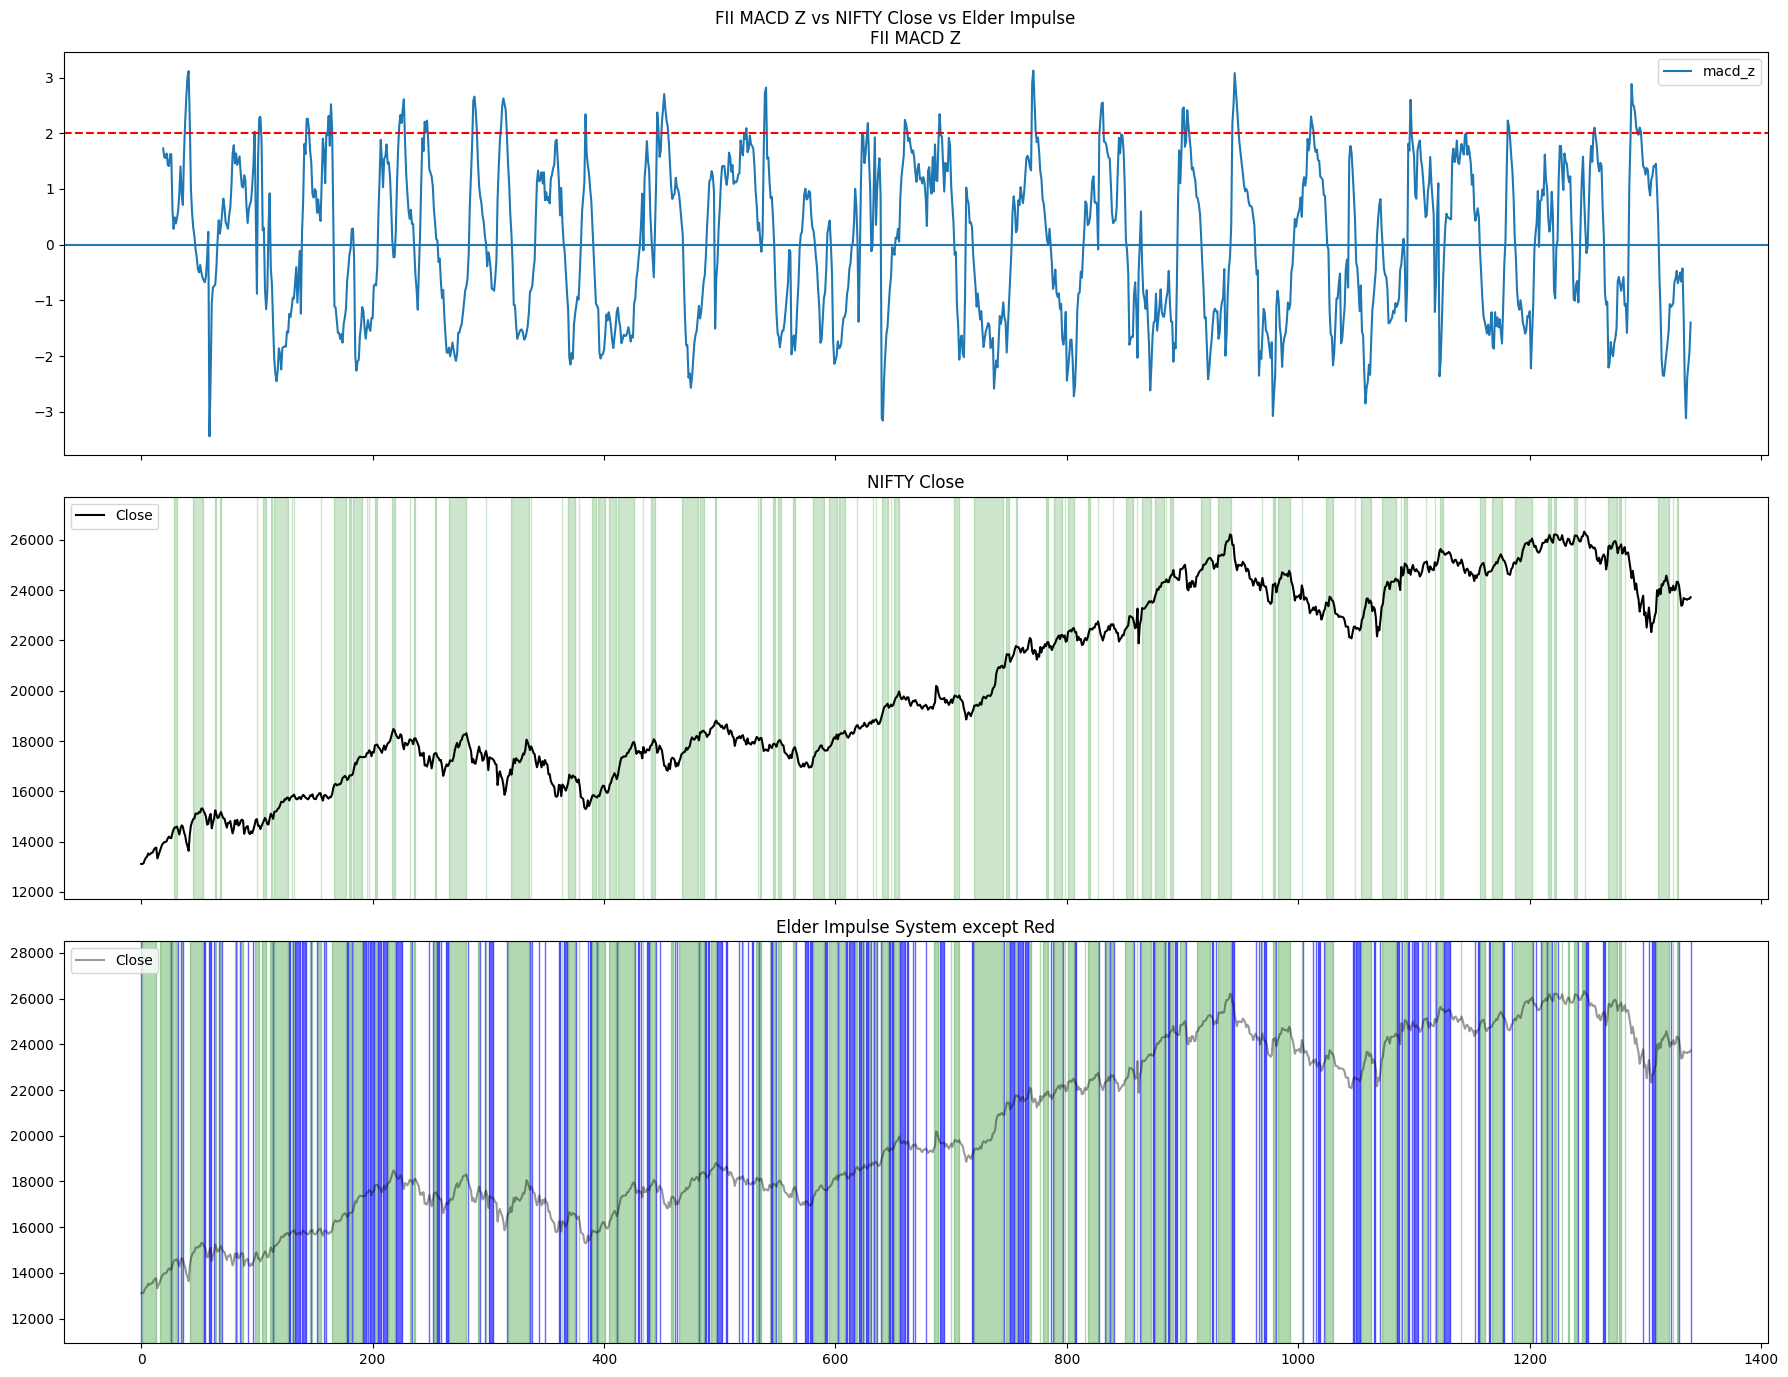

In [31]:

# =========================
# --- Plotting ---
# =========================

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# ======================================================
# --- First subplot : MACD Z ---
# ======================================================

fii_fig['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])

# ======================================================
# --- Second subplot : Close with backgrounds ---
# ======================================================

fii_fig['Close'].plot(ax=axes[1], color='black')

# Green regime background
condition_green = (fii_fig['macd_z'] < 0.5) & (fii_fig['impulse'] == 'green')

axes[1].fill_between(
    fii_fig.index,
    0,
    1,
    where=condition_green,
    color='green',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
)
'''
# Yellow extreme background
condition_bottom_form = fii_fig['macd_z'] < -1.75

axes[1].fill_between(
    fii_fig.index,
    0,
    1,
    where=condition_bottom_form,
    color='yellow',
    alpha=0.6,
    transform=axes[1].get_xaxis_transform()
)
'''
axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])

# ======================================================
# --- Third subplot : Elder Impulse ---
# ======================================================

# Plot close lightly in background
fii_fig['Close'].plot(
    ax=axes[2],
    color='black',
    alpha=0.4
)

# Green impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'green',
    color='green',
    alpha=0.3,
    transform=axes[2].get_xaxis_transform()
)
'''
# Red impulse background
axes[2].fill_between(
    combined.index,
    0,
    1,
    where=combined['impulse'] == 'red',
    color='red',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)
'''
# Blue impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'blue',
    color='blue',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)

axes[2].set_title('Elder Impulse System except Red')
axes[2].legend(['Close'])



# ======================================================
# --- Final Layout ---
# ======================================================

plt.suptitle('FII MACD Z vs NIFTY Close vs Elder Impulse')

plt.tight_layout()

plt.show()

In [32]:
fii_fig=fii_fig.tail(250)

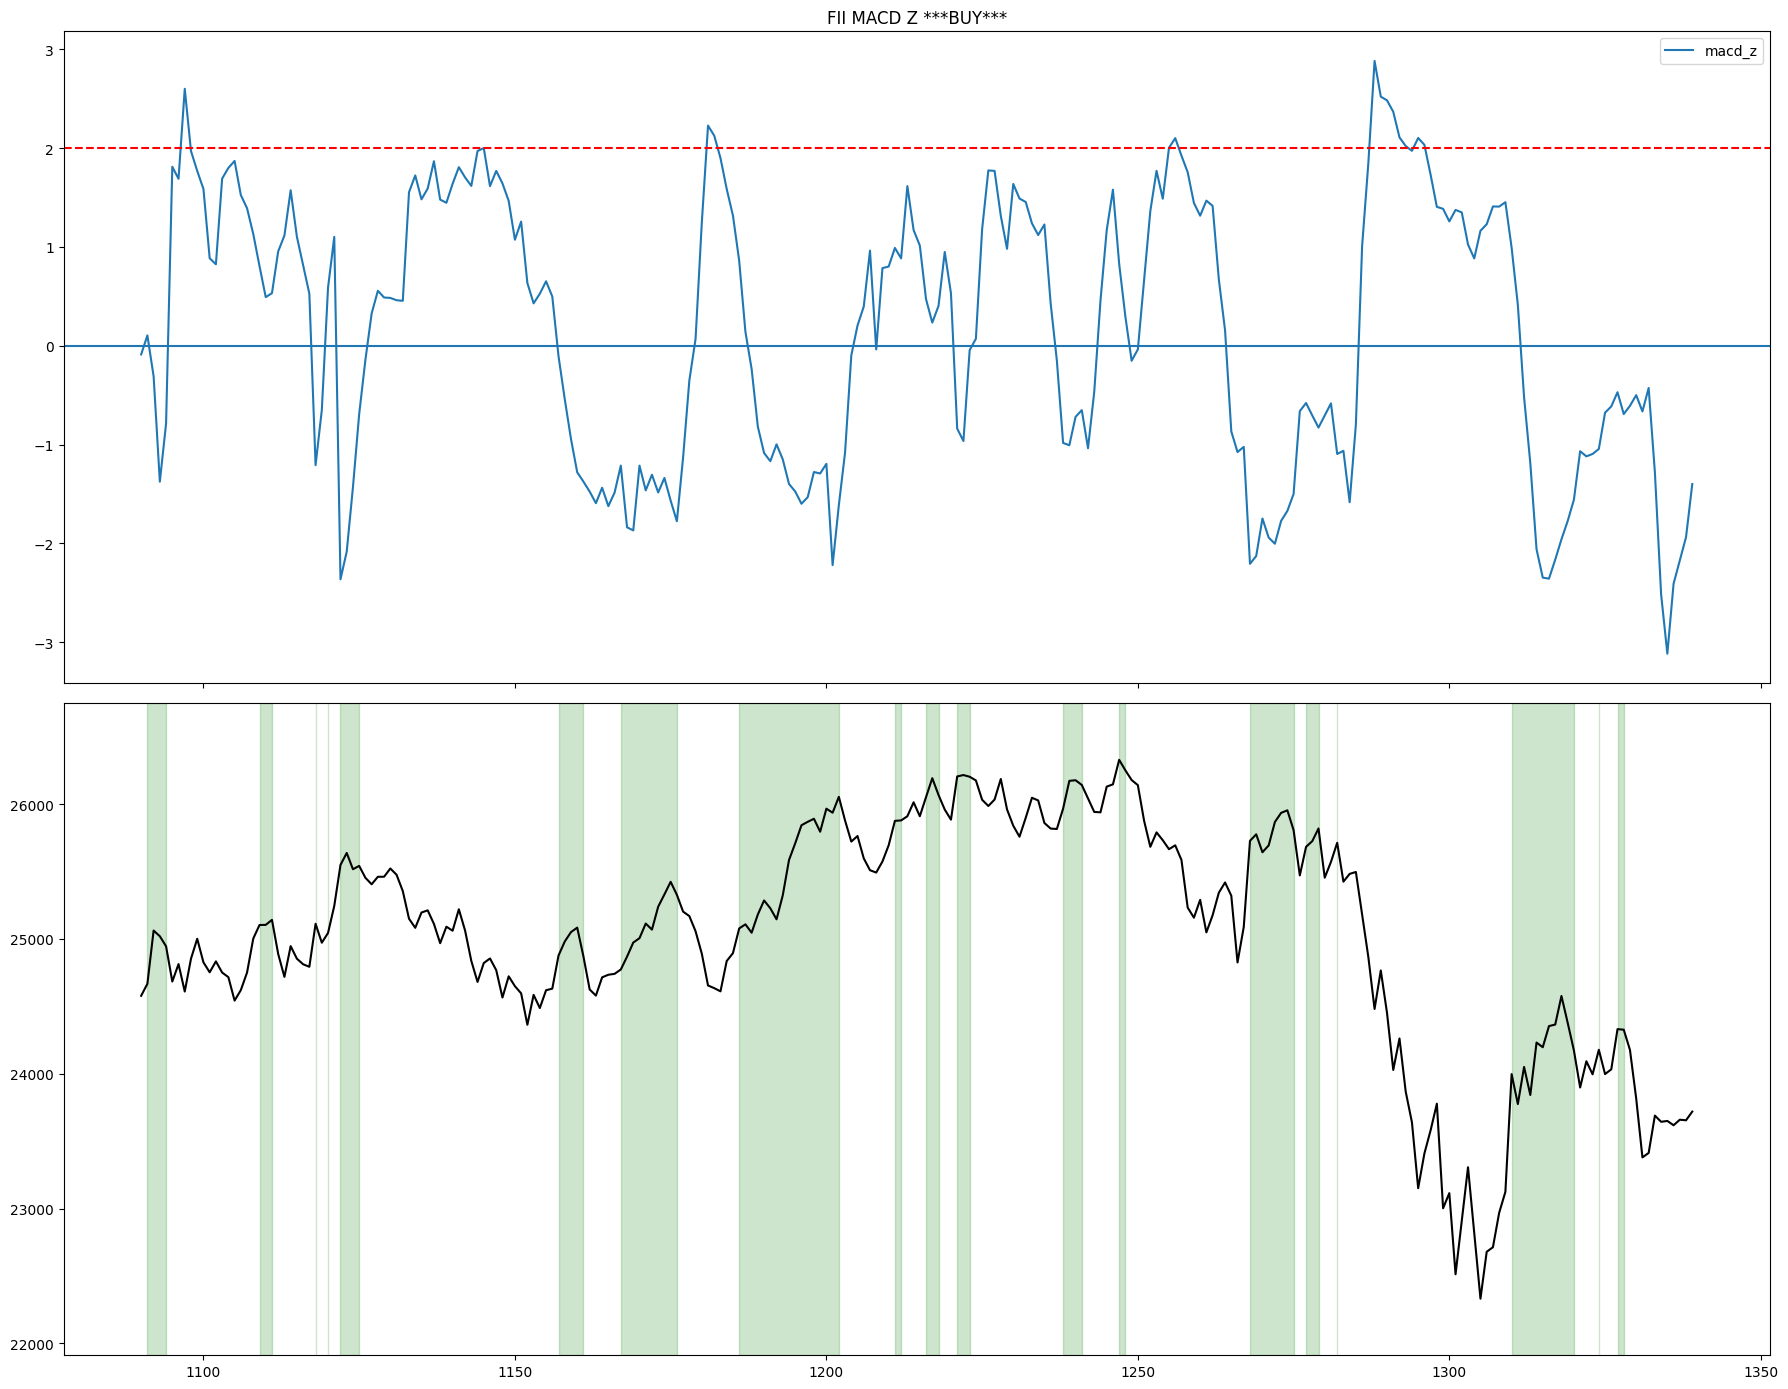

In [33]:

# =========================
# --- Plotting ---
# =========================

fig, axes = plt.subplots(2, 1, figsize=(18, 14), sharex=True)

# ======================================================
# --- First subplot : MACD Z ---
# ======================================================

fii_fig['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z ***BUY***')
axes[0].legend(['macd_z'])

# ======================================================
# --- Second subplot : Close with backgrounds ---
# ======================================================

fii_fig['Close'].plot(ax=axes[1], color='black')

# Green regime background
condition_green = (fii_fig['macd_z'] < 1) & (fii_fig['impulse'] =='green')

axes[1].fill_between(
    fii_fig.index,
    0,
    1,
    where=condition_green,
    color='green',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
    )


plt.tight_layout()

plt.show()

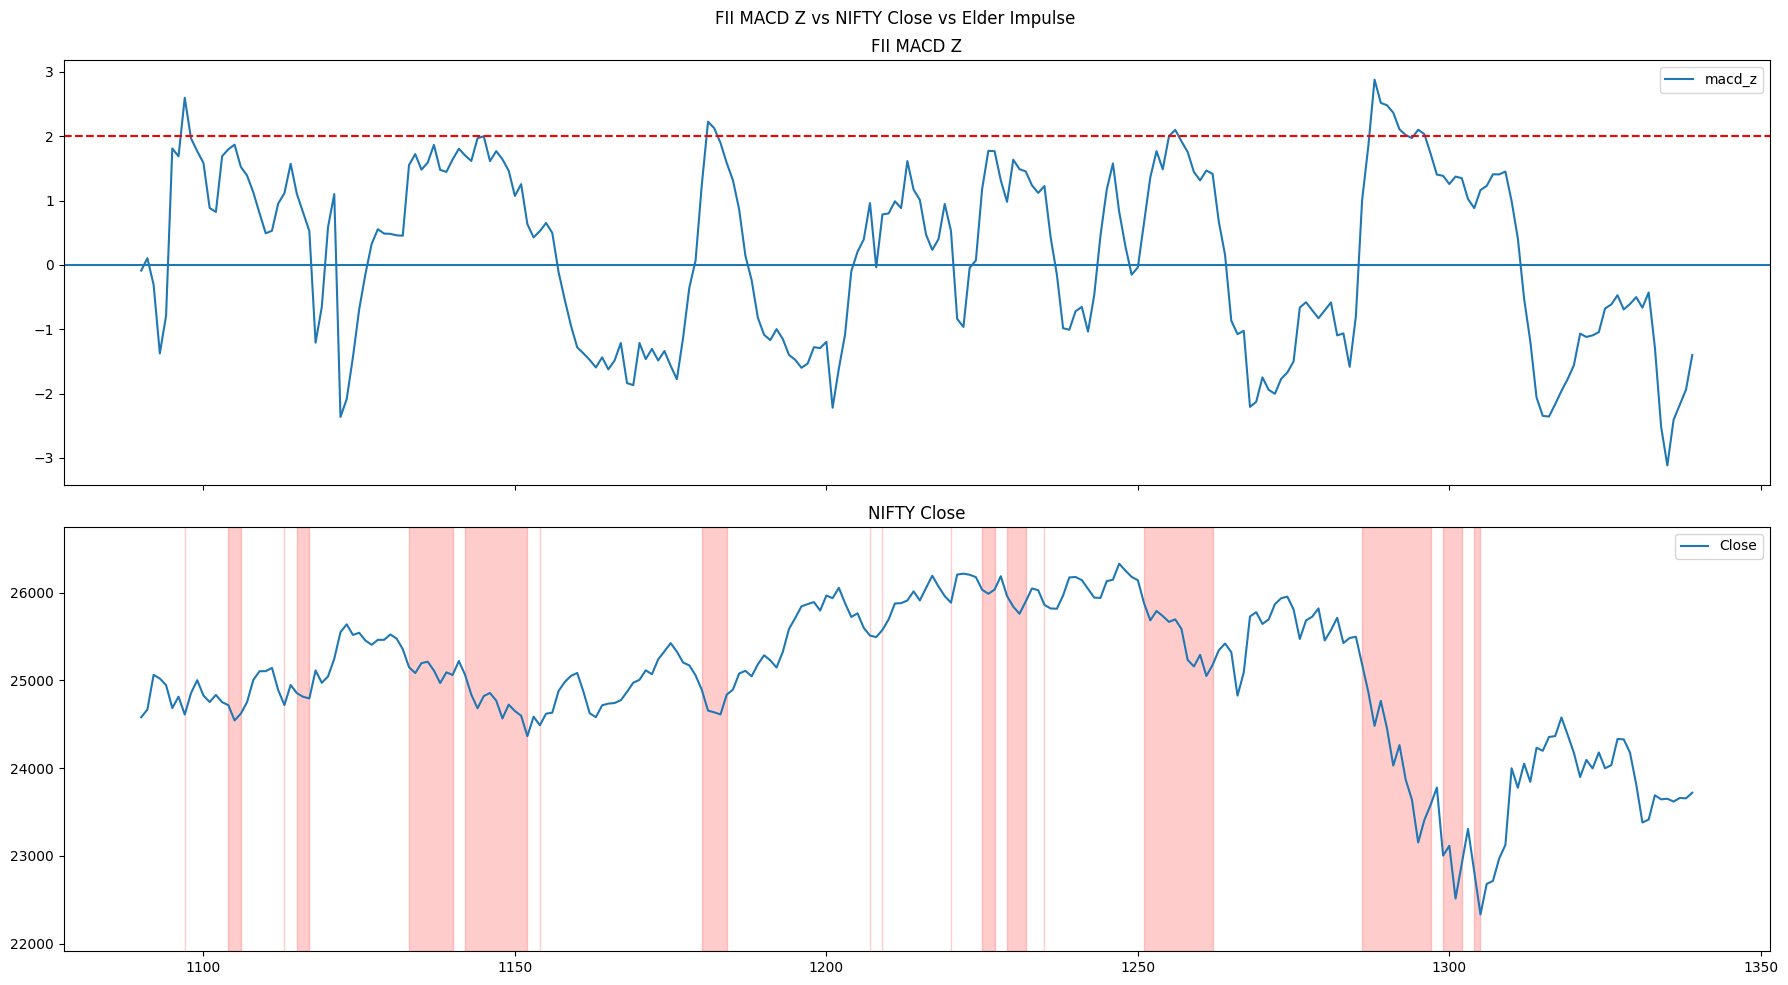

In [34]:

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- First subplot ---
fii_fig['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])

# --- Second subplot ---
fii_fig['Close'].plot(ax=axes[1])

# Condition
condition = (fii_fig['macd_z'] > 0.5) & (fii_fig['impulse'] == 'red')

# Red background
axes[1].fill_between(
    fii_fig.index,
    0,
    1,
    where=condition,
    color='red',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
)

axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])
'''
# ======================================================
# --- Third subplot : Elder Impulse ---
# ======================================================

# Plot close lightly in background
fii_fig['Close'].plot(
    ax=axes[2],
    color='black',
    alpha=0.4
)

# Green impulse background
axes[2].fill_between(
    combined.index,
    0,
    1,
    where=combined['impulse'] == 'green',
    color='green',
    alpha=0.3,
    transform=axes[2].get_xaxis_transform()
)

# Red impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'red',
    color='red',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)

# Blue impulse background
axes[2].fill_between(
    fii_fig.index,
    0,
    1,
    where=fii_fig['impulse'] == 'blue',
    color='blue',
    alpha=0.6,
    transform=axes[2].get_xaxis_transform()
)

axes[2].set_title('Elder Impulse System except Green')
axes[2].legend(['Close'])
'''


# ======================================================
# --- Final Layout ---
# ======================================================

plt.suptitle('FII MACD Z vs NIFTY Close vs Elder Impulse')

plt.tight_layout()

plt.show()

In [35]:
fii_fig['macd_regime'] = pd.cut(
    fii_fig['macd_z'],
    bins=[-np.inf,-1,-0.5,0,0.5,1,np.inf],
    labels=[
        'panic_selling',
        'strong_selling',
        'weak_selling',
        'weak_buying',
        'strong_buying',
        'euphoria'
    ]
)

In [36]:
fii_fig['ret_10d'] = (fii_fig['Close'].shift(-10) / fii_fig['Close'] - 1)*100

fii_fig.groupby('macd_regime')['ret_10d'].mean()

,ret_10d
macd_regime,
panic_selling,-0.534643
strong_selling,-1.446182
weak_selling,-0.293106
weak_buying,-0.087889
strong_buying,1.009926
euphoria,0.087775


In [37]:
#fii_fig["Date"] = pd.to_datetime(fii_fig["Date"])

regime_slice = (
    fii_fig
    .set_index("Date")
    .loc[:, ["macd_regime","ret_10d"]]
)

In [38]:
regime_slice.tail(5)

,macd_regime,ret_10d
Date,,
2026-05-18,panic_selling,NaN
2026-05-19,panic_selling,NaN
2026-05-20,panic_selling,NaN
2026-05-21,panic_selling,NaN
2026-05-22,panic_selling,NaN


In [39]:
fii_fig['macd_regime'].iloc[-1]

'panic_selling'

In [40]:
fii_fig.groupby('macd_regime')['ret_10d'].median()*100

,ret_10d
macd_regime,
panic_selling,-73.490414
strong_selling,-120.920599
weak_selling,-53.770962
weak_buying,-13.038648
strong_buying,100.201182
euphoria,28.964306


In [41]:
fii_fig['trend_regime'] = np.where(
    fii_fig['Close'] > fii_fig['MA20'],
    'above_MA20',
    'below_MA20'
)

In [42]:
pd.pivot_table(
    fii_fig,
    values='ret_10d',
    index='macd_regime',
    columns='trend_regime',
    aggfunc='mean'
)

trend_regime,above_MA20,below_MA20
macd_regime,,
panic_selling,-0.576203,-0.202170
strong_selling,-1.239354,-2.532030
weak_selling,-0.705839,1.220250
weak_buying,-0.290318,0.600369
strong_buying,0.560869,1.622277
euphoria,0.176945,0.057164


In [43]:
# MACD crossover conditions
fii_fig['macd_cross_up'] = (
    (fii_fig['macd'] > fii_fig['signal']) &
    (fii_fig['macd'].shift(1) <= fii_fig['signal'].shift(1))
)

fii_fig['macd_cross_down'] = (
    (fii_fig['macd'] < fii_fig['signal']) &
    (fii_fig['macd'].shift(1) >= fii_fig['signal'].shift(1))
)

In [44]:
fii_fig['ret_10d'] = fii_fig['Close'].shift(-20) / fii_fig['Close'] - 1

In [45]:

fii_fig['macd_event'] = np.select(
    [fii_fig['macd_cross_up'], fii_fig['macd_cross_down']],
    ['bullish_cross', 'bearish_cross'],
    default='no_cross'
)

In [46]:
result = fii_fig.groupby('macd_event')['ret_10d'].agg(
    count='count',
    mean='mean',
    median='median',
    win_rate=lambda x: (x > 0).mean()
)

print(result)

               count      mean    median  win_rate
macd_event                                        
bearish_cross      3 -0.017326 -0.002412  0.333333
bullish_cross      4 -0.005929 -0.006228  0.250000
no_cross         223 -0.002450  0.004513  0.534979


In [47]:
fii_fig['position'] = 0

fii_fig.loc[fii_fig['macd_cross_up'], 'position'] = 1
fii_fig.loc[fii_fig['macd_cross_down'], 'position'] = 0

fii_fig['position'] = fii_fig['position'].replace(to_replace=0, method='ffill')

In [48]:
fii_fig['ret'] = fii_fig['Close'].pct_change()
fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']
performance = {
    "mean_daily_return": fii_fig['strategy_ret'].mean(),
    "total_return": (1 + fii_fig['strategy_ret']).prod() - 1,
    "win_rate": (fii_fig['strategy_ret'] > 0).mean()
}

print(performance)

{'mean_daily_return': np.float64(-0.0001916595007213071), 'total_return': np.float64(-0.05357890998759163), 'win_rate': np.float64(0.412)}


In [49]:
fii_fig['ma50'] = fii_fig['Close'].rolling(20).mean()
fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']

fii_fig['nifty_above_ma50'] = fii_fig['Close'] > fii_fig['ma50']

In [50]:
fii_fig['long_regime'] = (
    fii_fig['fii_macd_bullish'] &
    fii_fig['nifty_above_ma50']
)
fii_fig['position'] = fii_fig['long_regime'].astype(int)

In [51]:
fii_fig['ret'] = fii_fig['Close'].pct_change()

fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']

In [52]:
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & fii_fig['nifty_above_ma50'],
    'bullish_flow_uptrend',
    'other'
)

print(
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

                      count      mean    median  <lambda_0>
regime                                                     
bullish_flow_uptrend     75  0.001983  0.001299        0.60
other                   174 -0.001012 -0.000331        0.48


In [53]:
# 20 DMA
fii_fig['ma20'] = fii_fig['Close'].rolling(20).mean()

# distance from MA20
fii_fig['dist_ma20'] = (fii_fig['Close'] - fii_fig['ma20']) / fii_fig['ma20']

conditions = [
    fii_fig['dist_ma20'] > 0.02,
    fii_fig['dist_ma20'].between(0, 0.02),
    fii_fig['dist_ma20'] < 0
]

choices = [
    'strong_uptrend',
    'weak_uptrend',
    'bearish'
]

fii_fig['trend_regime'] = np.select(conditions, choices, default='neutral')

In [54]:

fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & (fii_fig['dist_ma20'].between(0.03,1)),
    'flow_trend_bullish',
    'other'
)
fii_fig['ret'] = fii_fig['Close'].pct_change()

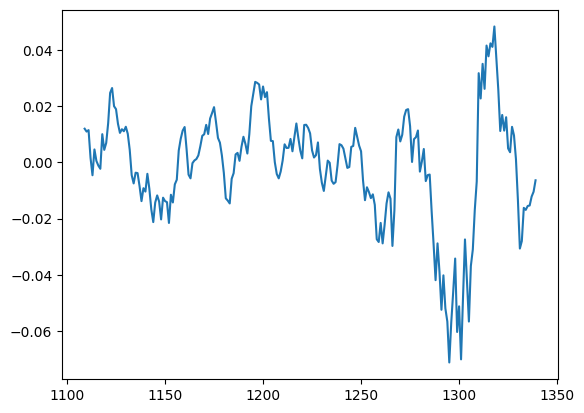

In [55]:
fii_fig['dist_ma20'].plot();

In [56]:
result = (
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

print(result)

                    count      mean    median  <lambda_0>
regime                                                   
flow_trend_bullish      8  0.008976  0.007586    0.750000
other                 241 -0.000411  0.000129    0.508264


In [57]:
df = fii_fig[fii_fig['macd'] > 0].copy()

In [58]:


bins = [0,0.02,0.04,0.06,0.08,.1]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [59]:
df['ret'] = df['Close'].pct_change()

In [60]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


              count      mean    median  win_rate
dist_bin                                         
(0.0, 0.02]      88  0.000964  0.000286  0.545455
(0.02, 0.04]     12  0.001438  0.002230  0.666667
(0.04, 0.06]      2 -0.021870 -0.021870  0.500000
(0.06, 0.08]      0       NaN       NaN       NaN
(0.08, 0.1]       0       NaN       NaN       NaN


In [61]:
df = fii_fig[fii_fig['macd'] <= 0].copy()

In [62]:
bins = [-.1,-0.08,-0.06,-0.04,-0.02,0]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [63]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


                count      mean    median  win_rate
dist_bin                                           
(-0.1, -0.08]       0       NaN       NaN       NaN
(-0.08, -0.06]      3 -0.026435 -0.026038  0.000000
(-0.06, -0.04]     11 -0.004546 -0.009540  0.454545
(-0.04, -0.02]     17 -0.001705 -0.002972  0.470588
(-0.02, 0.0]       39  0.000872  0.000551  0.564103


In [64]:
fii_fig["exit_signal"] = fii_fig["Close"] < fii_fig["ma20"]

In [65]:
fii_fig["entry_signal"] = (
    (fii_fig["Close"] > fii_fig["ma20"]) &
    (fii_fig["macd"] > fii_fig['signal10']) &
    #(fii_fig["dist_ma20"] > 0) &
    (fii_fig["impulse"] == "green")
)

In [66]:
position = 0
entry_price = 0

trades = []

for i in range(len(fii_fig)):

    price = fii_fig["Close"].iloc[i]

    if position == 0:

        if fii_fig["entry_signal"].iloc[i]:
            position = 1
            entry_price = price
            entry_date = fii_fig.index[i]

    elif position == 1:

        if fii_fig["exit_signal"].iloc[i]:

            exit_price = price
            exit_date = fii_fig.index[i]

            ret = (exit_price / entry_price) - 1

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "return": ret
            })

            position = 0

In [67]:
trades_df = pd.DataFrame(trades)

In [68]:
fii_fig.columns

Index(['Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash', 'macdy',
       'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10', 'hist',
       'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom', 'signal_dom',
       'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13', 'MA26', 'MA12',
       'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope', 'macd_slope',
       'impulse', 'macd_z', 'ema13', 'macd_regime', 'ret_10d', 'trend_regime',
       'macd_cross_up', 'macd_cross_down', 'macd_event', 'position', 'ret',
       'strategy_ret', 'ma50', 'fii_macd_bullish', 'nifty_above_ma50',
       'long_regime', 'regime', 'ma20', 'dist_ma20', 'exit_signal',
       'entry_signal'],
      dtype='object')

In [69]:
print(fii_fig['macd_regime'].tail(1))
print('\n\n\n')
print(fii_fig['trend_regime'].tail(1))

1339    panic_selling
Name: macd_regime, dtype: category
Categories (6, object): ['panic_selling' < 'strong_selling' < 'weak_selling' < 'weak_buying' <
                         'strong_buying' < 'euphoria']




1339    bearish
Name: trend_regime, dtype: object


In [70]:
stats = {
    "trades": len(trades_df),
    "mean_return": trades_df["return"].mean(),
    "median_return": trades_df["return"].median(),
    "win_rate": (trades_df["return"] > 0).mean(),
    "max_gain": trades_df["return"].max(),
    "max_loss": trades_df["return"].min(),
}

print(stats)

{'trades': 9, 'mean_return': np.float64(-0.0032322645814730766), 'median_return': -0.00756333511825269, 'win_rate': np.float64(0.2222222222222222), 'max_gain': 0.017228488315292667, 'max_loss': -0.010618966827389387}
